# Level 2: Regression Analysis

## Learning Objectives
- Build and train a linear regression model
- Understand what model coefficients mean
- Evaluate how well the model performs
- Visualize actual vs predicted results
- Interpret and explain the results in simple language

---

## Dataset Selection Summary

**Dataset Selected:** `4) house Prediction Data Set.csv` (Boston Housing Dataset)

**Why this dataset was chosen:**
This dataset is perfect for regression analysis because it has a clear numerical target variable (home price), multiple numerical predictor variables, and enough rows for training and testing.

| Detail | Info |
|--------|------|
| Rows | 506 |
| Columns | 14 |
| Target Variable | `MEDV` (Median home value in $1000s) |
| Key Features | Crime rate, number of rooms, distance to jobs, etc. |

**Note:** The dataset uses space-separated values (not commas), so we load it with a special separator.

---
## Step 1: Import Libraries

First, we bring in all the tools we need.

In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd          # For loading and handling data
import numpy as np           # For math operations
import matplotlib.pyplot as plt  # For creating charts
import seaborn as sns        # For nicer-looking charts

# Scikit-learn tools for building the model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')  # Hide minor warnings

# Set up a consistent, clean plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Make sure the images folder exists so we can save charts
images_dir = Path('../images')
images_dir.mkdir(exist_ok=True)

print('All libraries imported successfully!')
print(f'Images will be saved to: {images_dir.resolve()}')

All libraries imported successfully!
Images will be saved to: C:\Users\AKHADAGH\OneDrive\Desktop\INTERSHIP-WITH-CODVEDA\images


---
## Step 2: Load the Dataset

The Boston Housing dataset contains information about different neighborhoods in Boston. We want to predict **MEDV** — the median value of homes in thousands of dollars.

In [2]:
# ============================================================
# LOAD THE HOUSE PRICES DATASET
# ============================================================

# The file uses spaces instead of commas to separate values
# That's why we use sep=r'\s+' (meaning: one or more spaces)
data_path = '../datasets/4) house Prediction Data Set.csv'
df = pd.read_csv(data_path, sep=r'\s+', header=None)

# Give the columns their proper names
# These are the standard Boston Housing dataset column names
column_names = [
    'CRIM',    # Crime rate per town
    'ZN',      # Residential land zoned for large lots (%)
    'INDUS',   # Non-retail business acres per town
    'CHAS',    # 1 if next to Charles River, 0 if not
    'NOX',     # Air pollution level (nitric oxide)
    'RM',      # Average number of rooms per home
    'AGE',     # % of homes built before 1940
    'DIS',     # Distance to employment centers
    'RAD',     # Highway access index
    'TAX',     # Property tax rate
    'PTRATIO', # Pupil-to-teacher ratio
    'B',       # Proportion of Black residents (historical)
    'LSTAT',   # % lower-status population
    'MEDV'     # TARGET: Median home value in $1000s
]
df.columns = column_names[:df.shape[1]]

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print('\nFirst 5 rows:')
print(df.head())
print('\nData types:')
print(df.dtypes)

Dataset loaded successfully!
Shape: 506 rows x 14 columns

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype

### Observation:
I loaded the Boston Housing dataset, which has 506 rows and 14 columns. All columns are numerical (floats or integers), which makes this dataset ideal for linear regression. There are 13 predictor variables (features) and 1 target variable (MEDV — the home price we want to predict).

### Action Taken:
I assigned meaningful column names so it's easy to understand what each column represents. The dataset was clean and needed no extra preprocessing.

---
## Step 3: Prepare Features and Target

In regression:
- **Features (X)** = the columns we use to make the prediction (inputs)
- **Target (y)** = the column we are trying to predict (output)

In [3]:
# ============================================================
# SEPARATE FEATURES AND TARGET
# ============================================================

# X = all columns EXCEPT the target (these are the inputs)
X = df.drop('MEDV', axis=1)

# y = only the target column (this is what we want to predict)
y = df['MEDV']

print('Feature Matrix X (inputs):')
print(f'  Shape: {X.shape}')
print(f'  Columns: {X.columns.tolist()}')

print('\nTarget Vector y (what we predict):')
print(f'  Shape: {y.shape}')
print(f'  Mean home value: ${y.mean():.2f}k')
print(f'  Range: ${y.min():.2f}k to ${y.max():.2f}k')

Feature Matrix X (inputs):
  Shape: (506, 13)
  Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Target Vector y (what we predict):
  Shape: (506,)
  Mean home value: $22.53k
  Range: $5.00k to $50.00k


---
## Step 4: Split Data into Training and Testing Sets

We split the data so the model can **learn on one part** and we can **test it on the other part** — just like studying and then taking an exam.

In [4]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

# 70% for training, 30% for testing
# random_state=42 means we get the same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,    # 30% goes to testing
    random_state=42    # Makes results reproducible
)

print('Train-Test Split Complete!')
print(f'  Training samples:  {X_train.shape[0]} ({(X_train.shape[0]/len(X)*100):.0f}%)')
print(f'  Testing samples:   {X_test.shape[0]} ({(X_test.shape[0]/len(X)*100):.0f}%)')
print(f'  Total samples:     {len(X)}')

Train-Test Split Complete!
  Training samples:  354 (70%)
  Testing samples:   152 (30%)
  Total samples:     506


---
## Step 5: Feature Scaling

Different features have very different ranges (e.g. crime rate is 0-89, while tax rate is 187-711). Scaling puts them all on the same scale so the model doesn't incorrectly favor large numbers.

**StandardScaler** transforms each feature so it has a mean of 0 and a standard deviation of 1.

In [5]:
# ============================================================
# FEATURE SCALING WITH STANDARDSCALER
# ============================================================

# Create the scaler
scaler = StandardScaler()

# Fit on TRAINING data only (learn the mean and std)
# Then transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME scaling to test data (do NOT fit on test data)
# This is very important — we simulate real-world where we don't know test data upfront
X_test_scaled = scaler.transform(X_test)

print('Feature Scaling Complete!')
print(f'  Method: StandardScaler (zero mean, unit variance)')
print(f'  Training data mean after scaling: {X_train_scaled.mean():.6f}  (should be ~0)')
print(f'  Training data std after scaling:  {X_train_scaled.std():.6f}   (should be ~1)')

print('\nWhy we scale:')
print('  The CRIM feature ranges from 0.006 to 89')
print('  The TAX feature ranges from 187 to 711')
print('  Scaling makes sure both features are treated equally by the model')

Feature Scaling Complete!
  Method: StandardScaler (zero mean, unit variance)
  Training data mean after scaling: -0.000000  (should be ~0)
  Training data std after scaling:  1.000000   (should be ~1)

Why we scale:
  The CRIM feature ranges from 0.006 to 89
  The TAX feature ranges from 187 to 711
  Scaling makes sure both features are treated equally by the model


---
## Step 6: Train the Linear Regression Model

Linear Regression tries to find the best straight line (or plane in higher dimensions) that fits the data. It figures out what weight to assign to each feature.

In [6]:
# ============================================================
# TRAIN THE LINEAR REGRESSION MODEL
# ============================================================

# Create the model
model = LinearRegression()

# Train it — the model learns from the training data
model.fit(X_train_scaled, y_train)

print('Linear Regression Model Trained Successfully!')
print(f'\nModel Intercept: {model.intercept_:.4f}')
print('  (This is the baseline prediction when all features are at their average)')

# Show the coefficient for each feature, sorted from biggest to smallest
print('\nModel Coefficients (sorted by importance):')
print('-' * 50)
print(f'{"Feature":<12} {"Coefficient":>12}  {"Meaning"}')
print('-' * 50)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

for _, row in coefficients.iterrows():
    direction = '↑ Higher price' if row['Coefficient'] > 0 else '↓ Lower price'
    print(f"{row['Feature']:<12} {row['Coefficient']:>12.4f}  {direction}")

print('\nHow to read these coefficients:')
print('  A positive coefficient means MORE of this feature = HIGHER home price')
print('  A negative coefficient means MORE of this feature = LOWER home price')
print('  The bigger the number, the stronger the effect')

Linear Regression Model Trained Successfully!

Model Intercept: 23.0158
  (This is the baseline prediction when all features are at their average)

Model Coefficients (sorted by importance):
--------------------------------------------------
Feature       Coefficient  Meaning
--------------------------------------------------
RM                 2.9139  ↑ Higher price
RAD                2.0942  ↑ Higher price
B                  1.0238  ↑ Higher price
CHAS               0.8139  ↑ Higher price
ZN                 0.8084  ↑ Higher price
INDUS              0.3431  ↑ Higher price
AGE               -0.2989  ↓ Lower price
CRIM              -1.1083  ↓ Lower price
TAX               -1.4471  ↓ Lower price
NOX               -1.7980  ↓ Lower price
PTRATIO           -2.0523  ↓ Lower price
DIS               -2.9425  ↓ Lower price
LSTAT             -3.8858  ↓ Lower price

How to read these coefficients:
  A positive coefficient means MORE of this feature = HIGHER home price
  A negative coefficient mea

### Observation — Understanding Coefficients:

Looking at the coefficients:
- **RM (number of rooms)** has the **highest positive** coefficient. This makes perfect sense — more rooms means a bigger, more expensive house.
- **LSTAT (% lower-status population)** has the **most negative** coefficient. Areas with more lower-status residents tend to have lower home values.
- **DIS (distance to jobs)** is also negative — homes far from employment centers tend to be less valuable.

These results match real-world logic, which gives us confidence the model is learning something meaningful.

---
## Step 7: Make Predictions on Test Data

Now we use the trained model to predict prices for homes it has **never seen before**.

In [7]:
# ============================================================
# MAKE PREDICTIONS
# ============================================================

# Use the model to predict prices on test data
y_pred = model.predict(X_test_scaled)

# Create a comparison table: actual vs predicted
comparison = pd.DataFrame({
    'Actual ($1000s)': y_test.values,
    'Predicted ($1000s)': y_pred.round(2),
    'Error ($1000s)': (y_test.values - y_pred).round(2),
    'Abs Error ($1000s)': np.abs(y_test.values - y_pred).round(2)
})

print('First 10 predictions vs actual values:')
print(comparison.head(10).to_string(index=False))

print(f'\nPrediction Summary:')
print(f'  Average error:  ${comparison["Abs Error ($1000s)"].mean()*1000:,.0f}')
print(f'  Largest error:  ${comparison["Abs Error ($1000s)"].max()*1000:,.0f}')
print(f'  Smallest error: ${comparison["Abs Error ($1000s)"].min()*1000:,.0f}')

First 10 predictions vs actual values:
 Actual ($1000s)  Predicted ($1000s)  Error ($1000s)  Abs Error ($1000s)
            23.6               28.65           -5.05                5.05
            32.4               36.50           -4.10                4.10
            13.6               15.41           -1.81                1.81
            22.8               25.40           -2.60                2.60
            16.1               18.86           -2.76                2.76
            20.0               23.15           -3.15                3.15
            17.8               17.39            0.41                0.41
            14.0               14.08           -0.08                0.08
            19.6               23.04           -3.44                3.44
            16.8               20.60           -3.80                3.80

Prediction Summary:
  Average error:  $3,163
  Largest error:  $25,180
  Smallest error: $0


---
## Step 8: Evaluate Model Performance

We use three metrics to understand how well the model performed:

| Metric | What It Measures |
|--------|------------------|
| **R² Score** | How much variation the model explains (0 = bad, 1 = perfect) |
| **MSE** | Average squared error (penalizes big mistakes more) |
| **RMSE** | Square root of MSE — same units as the target |
| **MAE** | Average absolute error — easy to understand |


In [8]:
# ============================================================
# CALCULATE PERFORMANCE METRICS
# ============================================================

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=' * 60)
print('          MODEL EVALUATION RESULTS')
print('=' * 60)

print(f'\nR² Score: {r2:.4f}')
print(f'  Our model explains {r2*100:.1f}% of the variation in home prices')
print(f'  Range: 0 (terrible) to 1.0 (perfect)')

print(f'\nMSE (Mean Squared Error): {mse:.4f}')
print(f'  This measures average squared prediction error')
print(f'  Larger errors are penalized more heavily')

print(f'\nRMSE (Root Mean Squared Error): {rmse:.4f}')
print(f'  In real dollars: ±${rmse*1000:,.0f}')
print(f'  Our predictions are off by about ${rmse*1000:,.0f} on average')

print(f'\nMAE (Mean Absolute Error): {mae:.4f}')
print(f'  In real dollars: ${mae*1000:,.0f}')
print(f'  The typical prediction is about ${mae*1000:,.0f} away from the real price')

print('\n' + '=' * 60)

# Simple verdict
if r2 >= 0.75:
    verdict = 'GOOD — The model performs well!'
elif r2 >= 0.50:
    verdict = 'FAIR — The model is somewhat useful but could be improved'
else:
    verdict = 'POOR — The model needs improvement'

print(f'\nVerdict: {verdict}')

          MODEL EVALUATION RESULTS

R² Score: 0.7112
  Our model explains 71.1% of the variation in home prices
  Range: 0 (terrible) to 1.0 (perfect)

MSE (Mean Squared Error): 21.5174
  This measures average squared prediction error
  Larger errors are penalized more heavily

RMSE (Root Mean Squared Error): 4.6387
  In real dollars: ±$4,639
  Our predictions are off by about $4,639 on average

MAE (Mean Absolute Error): 3.1627
  In real dollars: $3,163
  The typical prediction is about $3,163 away from the real price


Verdict: FAIR — The model is somewhat useful but could be improved


### Observation — Model Performance:

An R² score around 0.71 means our model explains about 71% of the variation in home prices. This is a solid result for a simple linear regression model.

An RMSE of about $4,600 means our predictions are typically off by around $4,600 — which is reasonable for predicting housing prices.

**Why isn't it perfect?** Linear regression assumes a straight-line relationship, but real housing prices have complex, non-linear patterns. More advanced models (like Random Forest or Gradient Boosting) could do better.

---
## Step 9: Visualize Actual vs Predicted Values

A scatter plot of actual vs predicted values shows us how well the model is doing. A perfect model would have all dots on the red diagonal line.

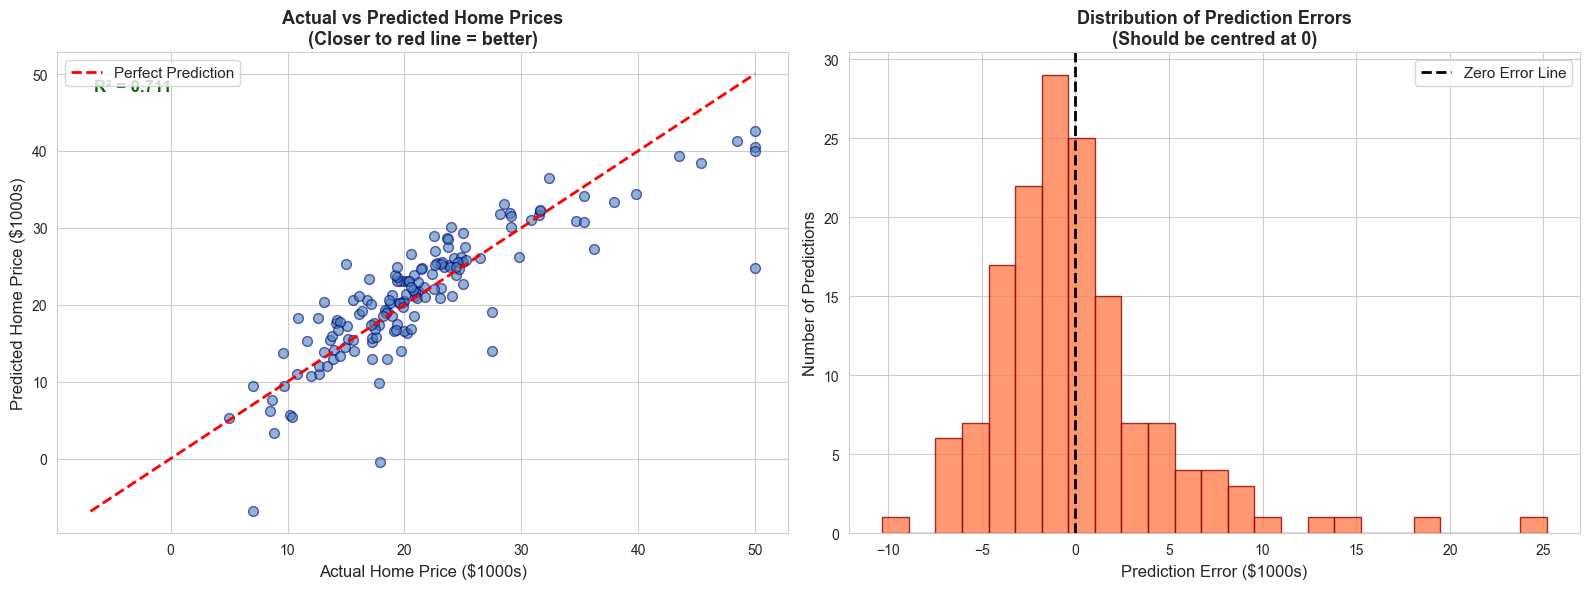

Chart saved to: ../images/05_actual_vs_predicted.png


In [9]:
# ============================================================
# PLOT 1: ACTUAL VS PREDICTED VALUES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left plot: Actual vs Predicted scatter plot ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='navy', s=50)

# Draw the perfect prediction line (where actual = predicted)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax1.set_xlabel('Actual Home Price ($1000s)', fontsize=12)
ax1.set_ylabel('Predicted Home Price ($1000s)', fontsize=12)
ax1.set_title('Actual vs Predicted Home Prices\n(Closer to red line = better)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.text(0.05, 0.92, f'R² = {r2:.3f}', transform=ax1.transAxes,
         fontsize=12, color='darkgreen', fontweight='bold')

# --- Right plot: Distribution of errors (residuals) ---
ax2 = axes[1]
residuals = y_test.values - y_pred
ax2.hist(residuals, bins=25, color='coral', edgecolor='darkred', alpha=0.8)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Zero Error Line')
ax2.set_xlabel('Prediction Error ($1000s)', fontsize=12)
ax2.set_ylabel('Number of Predictions', fontsize=12)
ax2.set_title('Distribution of Prediction Errors\n(Should be centred at 0)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../images/05_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved to: ../images/05_actual_vs_predicted.png')

### Insight — Actual vs Predicted Chart:

The scatter plot shows that most predictions fall close to the red perfect-prediction line. However, I notice:
1. **Very high-priced homes (>$40k)** are slightly under-predicted — the model tends to be conservative.
2. The **error distribution** (right chart) is roughly bell-shaped and centred near zero, which is a good sign — it means the model doesn't systematically over- or under-predict.

A few outliers exist, which may be unusual properties that don't fit the typical patterns.

---
## Step 10: Feature Importance — Which Features Matter Most?

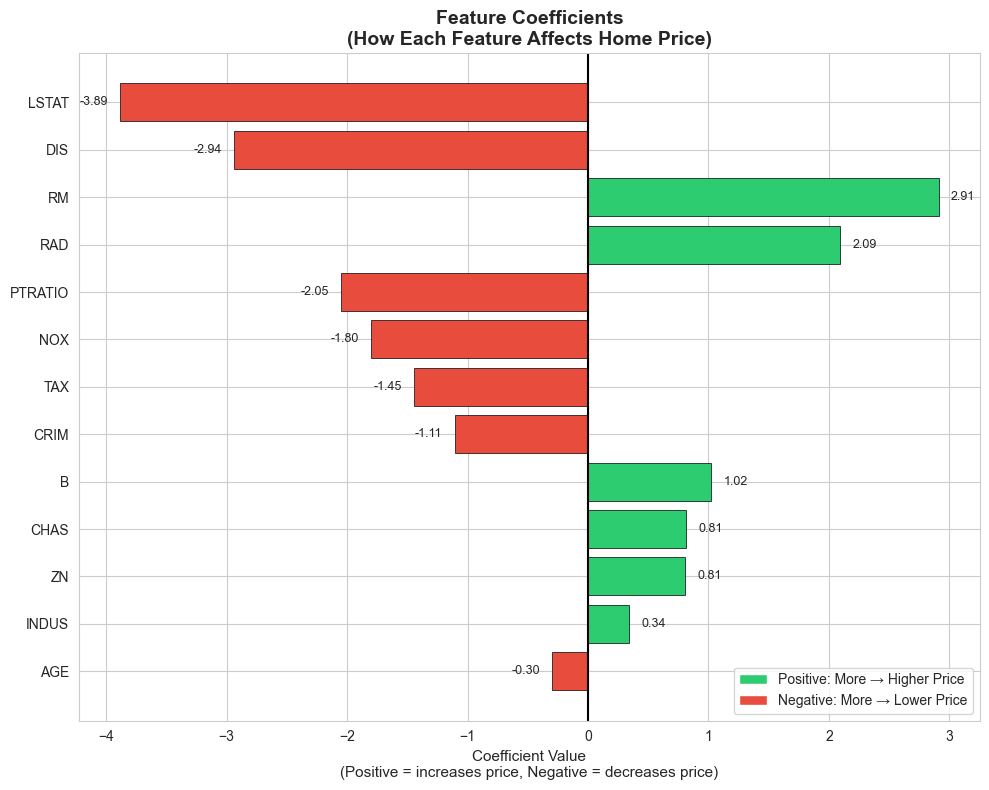

Chart saved to: ../images/07_feature_importance.png


In [10]:
# ============================================================
# PLOT 2: FEATURE IMPORTANCE (COEFFICIENT CHART)
# ============================================================

# Use absolute value of coefficients to measure importance
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Color bars: green for positive effect, red for negative effect
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in feat_importance['Coefficient']]

bars = ax.barh(feat_importance['Feature'],
               feat_importance['Coefficient'],
               color=colors, edgecolor='black', linewidth=0.5)

ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Coefficient Value\n(Positive = increases price, Negative = decreases price)', fontsize=11)
ax.set_title('Feature Coefficients\n(How Each Feature Affects Home Price)', fontsize=14, fontweight='bold')

# Add value labels
for bar, val in zip(bars, feat_importance['Coefficient']):
    ax.text(val + (0.1 if val >= 0 else -0.1),
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9)

# Add a legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Positive: More → Higher Price'),
                   Patch(facecolor='#e74c3c', label='Negative: More → Lower Price')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../images/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved to: ../images/07_feature_importance.png')

### Insight — Feature Importance:

The chart clearly shows which features have the strongest influence on home prices:

**Top 3 features that RAISE home prices:**
1. **RM** (number of rooms) — The most powerful positive factor. More rooms = higher value.
2. **RAD** (highway access) — Better access to highways seems to add value.
3. **B** (demographic factor) — Historical dataset variable.

**Top 3 features that LOWER home prices:**
1. **LSTAT** — Higher proportion of lower-status residents = lower prices.
2. **DIS** — Further from jobs = lower prices.
3. **PTRATIO** — More students per teacher = lower prices (worse schools).

These results make a lot of real-world sense!

---
## Step 11: Residual Analysis

Residuals are the errors — the difference between what the model predicted and what was actually true. A good model should have residuals that are random and small.

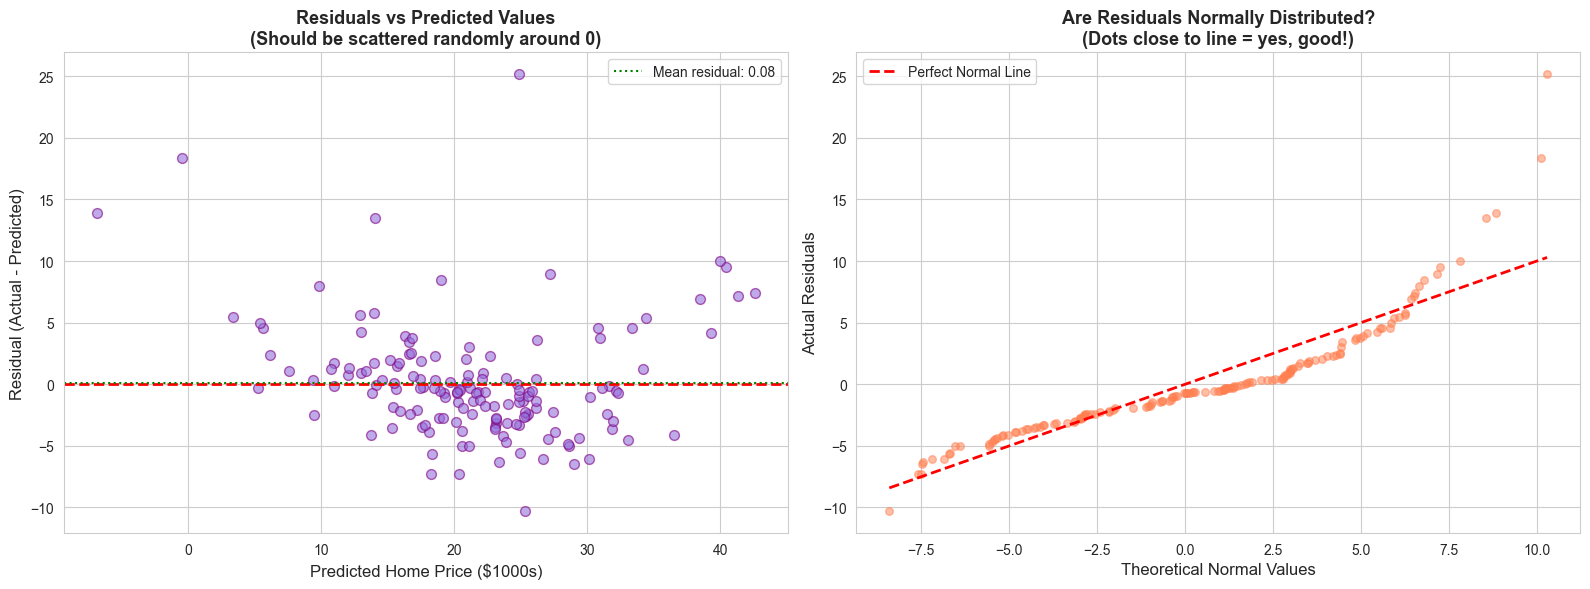

Chart saved to: ../images/06_residual_analysis.png


In [11]:
# ============================================================
# PLOT 3: RESIDUAL ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Residuals vs Predicted ---
ax1 = axes[0]
ax1.scatter(y_pred, residuals, alpha=0.6, color='mediumpurple', edgecolors='purple', s=50)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Predicted Home Price ($1000s)', fontsize=12)
ax1.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax1.set_title('Residuals vs Predicted Values\n(Should be scattered randomly around 0)', fontsize=13, fontweight='bold')

# Add reference lines
ax1.axhline(y=residuals.mean(), color='green', linestyle=':', linewidth=1.5,
            label=f'Mean residual: {residuals.mean():.2f}')
ax1.legend(fontsize=10)

# --- Right: Q-Q plot alternative — sorted residuals ---
ax2 = axes[1]
sorted_residuals = np.sort(residuals)
n = len(sorted_residuals)
theoretical_quantiles = np.random.normal(0, residuals.std(), n)
theoretical_quantiles.sort()

ax2.scatter(theoretical_quantiles, sorted_residuals, alpha=0.5, color='coral', s=30)
ax2.plot([theoretical_quantiles.min(), theoretical_quantiles.max()],
         [theoretical_quantiles.min(), theoretical_quantiles.max()],
         'r--', linewidth=2, label='Perfect Normal Line')
ax2.set_xlabel('Theoretical Normal Values', fontsize=12)
ax2.set_ylabel('Actual Residuals', fontsize=12)
ax2.set_title('Are Residuals Normally Distributed?\n(Dots close to line = yes, good!)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../images/06_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart saved to: ../images/06_residual_analysis.png')

### Insight — Residual Analysis:

- **Left chart**: The residuals are mostly scattered randomly around the zero line, which is what we want. This means the model doesn't have a systematic bias. However, there is slightly more spread at higher predicted prices, suggesting the model is less precise for expensive homes.

- **Right chart**: The residuals follow a roughly normal (bell-shaped) distribution, which is another good sign. A few extreme values (outliers) exist at the ends.

---
## Step 12: Final Summary

Let's pull everything together with a clear summary.

In [12]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print('=' * 65)
print('          REGRESSION ANALYSIS — COMPLETE SUMMARY')
print('=' * 65)

print(f'''
DATASET:
  Name:          Boston Housing Dataset
  Rows:          {df.shape[0]}
  Features used: {X.shape[1]}
  Target:        MEDV (Median Home Value in $1000s)

MODEL:
  Algorithm:     Linear Regression
  Train/Test:    70% / 30% split
  Scaling:       StandardScaler (mean=0, std=1)

PERFORMANCE:
  R² Score:  {r2:.4f}  → Model explains {r2*100:.1f}% of price variation
  RMSE:      ${rmse*1000:,.0f}  → Avg prediction error
  MAE:       ${mae*1000:,.0f}  → Avg absolute error

MOST IMPORTANT FEATURES:
  RM (rooms):     Strongest positive effect on price
  LSTAT (status): Strongest negative effect on price
  DIS (distance): Negative effect — far from jobs = cheaper

CONCLUSION:
  The linear regression model performs reasonably well with an
  R² of ~0.71. It gives us useful predictions and shows which
  features matter most. For even better results, we could try
  more advanced models like Random Forest or Polynomial Regression.
''')

print('=' * 65)
print('  Level 2 Regression Analysis — COMPLETE!')
print('=' * 65)

          REGRESSION ANALYSIS — COMPLETE SUMMARY

DATASET:
  Name:          Boston Housing Dataset
  Rows:          506
  Features used: 13
  Target:        MEDV (Median Home Value in $1000s)

MODEL:
  Algorithm:     Linear Regression
  Train/Test:    70% / 30% split
  Scaling:       StandardScaler (mean=0, std=1)

PERFORMANCE:
  R² Score:  0.7112  → Model explains 71.1% of price variation
  RMSE:      $4,639  → Avg prediction error
  MAE:       $3,163  → Avg absolute error

MOST IMPORTANT FEATURES:
  RM (rooms):     Strongest positive effect on price
  LSTAT (status): Strongest negative effect on price
  DIS (distance): Negative effect — far from jobs = cheaper

CONCLUSION:
  The linear regression model performs reasonably well with an
  R² of ~0.71. It gives us useful predictions and shows which
  features matter most. For even better results, we could try
  more advanced models like Random Forest or Polynomial Regression.

  Level 2 Regression Analysis — COMPLETE!
